# Analysis of Player Age and Minutes Played

This analysis investigates whether there is a statistically significant
difference in minutes played between older and younger players.

The analysis uses descriptive statistics, visualisations, confidence
intervals, hypothesis testing, effect size, and robustness checks.

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## 1. Data Loading and Initial Inspection

The player dataset is loaded using pandas. The first step is to inspect
the structure of the dataset and identify the variables required for
the analysis.

In [3]:
players = pd.read_csv("players.csv")

print("Dataset shape:", players.shape)
display(players.head())

Dataset shape: (1248, 72)


,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,26,1999,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,NaN,2,0,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Column names:")
print(players.columns.tolist())

print("\nMissing values:")
print(players[["player", "team", "position", "age", "minutes"]].isnull().sum())

Column names:
['player', 'team', 'team_country', 'position', 'age', 'birth_year', 'club', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90', 'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90', 'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90', 'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target', 'minutes_per_game', 'minutes_pct', 'minutes_per_start', 'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs', 'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus', 'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls', 'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won', 'pens_won', 'pens_conceded', 'own_goals', 'gk_games', 'gk_games_starts', 'gk_minutes', 'gk_goals_against', 'gk_goals_against_per90', 'gk_shots_on_target_against', 'gk_saves', 'gk_save_pct', 

## 2. Data Cleaning and Population Definition

The analysis focuses on players who appeared in at least one match.
Therefore, players with zero or missing minutes are excluded.

Rows with missing age or minutes are also removed because these variables
are required for the analysis.

In [5]:
df = players[
    players["minutes"].fillna(0) > 0
][["player", "team", "position", "age", "minutes"]].copy()

df = df.dropna(subset=["age", "minutes"])

print("Population size:", len(df))
display(df.head())

Population size: 1039


,player,team,position,age,minutes
1,Adil Boulbina,Algeria,FW,23,19.0
2,Amine Gouiri,Algeria,FW,26,251.0
3,Anis Hadj Moussa,Algeria,MF,24,98.0
4,Aïssa Mandi,Algeria,DF,34,360.0
5,Fares Chaïbi,Algeria,MF,23,360.0


## 3. Age Group Definition

Players are divided into two groups using the population median age.

Players above the median are classified as "Older", while players at or
below the median are classified as "Younger".

Using the median provides a data-driven cutoff and helps create relatively
balanced comparison groups without selecting an arbitrary age threshold.

In [6]:
median_age = df["age"].median()

df["age_group"] = np.where(
    df["age"] > median_age,
    "Older",
    "Younger"
)

print(f"Median age: {median_age:.1f}")

print("\nAge group counts:")
print(df["age_group"].value_counts())

print("\nAge group percentages:")
print(df["age_group"].value_counts(normalize=True) * 100)

Median age: 27.0

Age group counts:
age_group
Younger    555
Older      484
Name: count, dtype: int64

Age group percentages:
age_group
Younger    53.416747
Older      46.583253
Name: proportion, dtype: float64


Pearson r = 0.089, p = 0.004
Spearman r = 0.083, p = 0.007
Curve peaks around age 50.3


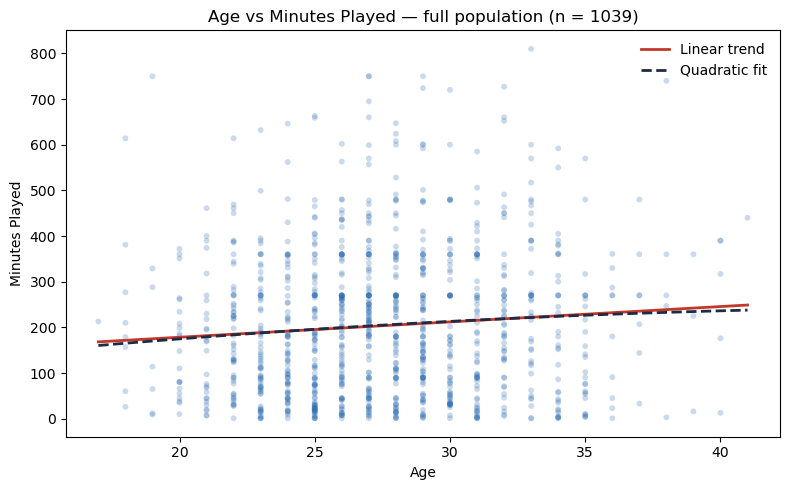

In [7]:


# Correlation between age and minutes across every player
pearson_r, pearson_p = stats.pearsonr(df.age, df.minutes)
spearman_r, spearman_p = stats.spearmanr(df.age, df.minutes)
print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3f}")

# Fit a quadratic curve to check for a rise-then-fall ("prime age") shape
coeffs = np.polyfit(df.age, df.minutes, 2)
a, b, c = coeffs
if a < 0:
    peak_age = -b / (2 * a)
    print(f"Curve peaks around age {peak_age:.1f}")
else:
    print("Curve doesn't peak within a realistic age range — minutes just drift upward")

# Scatter plot: age vs minutes, with a straight trend line and the curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.age, df.minutes, alpha=0.25, s=18, color="#2F6FB4", edgecolor="none")

# straight trend line
z = np.polyfit(df.age, df.minutes, 1)
age_range = np.linspace(df.age.min(), df.age.max(), 100)
ax.plot(age_range, np.polyval(z, age_range), color="#C0392B", linewidth=2, label="Linear trend")

# curved (quadratic) fit
ax.plot(age_range, np.polyval(coeffs, age_range), color="#1F2A44", linewidth=2,
        linestyle="--", label="Quadratic fit")

ax.set_xlabel("Age")
ax.set_ylabel("Minutes Played")
ax.set_title("Age vs Minutes Played — full population (n = %d)" % len(df))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("q1_age_scatter.png", dpi=200)
plt.show()

## 4. Random Sampling

A simple random sample of 60 players is selected from the cleaned
population.

A fixed random seed is used so that the analysis can be reproduced
consistently.

In [9]:
n_sample = 60

sample = df.sample(
    n=n_sample,
    random_state=2027
).reset_index(drop=True)

print(f"Sample size: {len(sample)}")
display(sample.head(10))

Sample size: 60


,player,team,position,age,minutes,age_group
0,Yerry Mina,Colombia,DF,31,2.0,Older
1,César Montes,Mexico,DF,29,314.0,Older
2,Taha Ali,Sweden,"FW,MF",27,37.0,Younger
3,Noor Al Rawabdeh,Jordan,MF,29,270.0,Older
4,Danilo,Brazil,DF,34,405.0,Older
5,Kevin Pina,Cabo Verde,MF,29,349.0,Older
6,Shoja' Khalilzadeh,IR Iran,DF,37,270.0,Older
7,Gervane Kastaneer,Curaçao,"FW,MF",30,30.0,Older
8,Santiago Arias,Colombia,DF,34,86.0,Older
9,Josip Stanišić,Croatia,"DF,MF",26,360.0,Younger


## 5. Descriptive Statistics

Descriptive statistics are calculated to understand the distribution of
minutes played in the sample.

The analysis includes the mean, median, standard deviation, minimum,
maximum, and skewness.

In [10]:
x = sample["minutes"]

desc = {
    "Sample size": len(x),
    "Mean": x.mean(),
    "Median": x.median(),
    "Standard deviation": x.std(ddof=1),
    "Minimum": x.min(),
    "Maximum": x.max(),
    "Skewness": stats.skew(x)
}

display(pd.Series(desc))

Sample size            60.000000
Mean                  214.233333
Median                207.000000
Standard deviation    184.137050
Minimum                 1.000000
Maximum               750.000000
Skewness                0.972172
dtype: float64

## 6. Distribution of Minutes Played

A histogram is used to examine the distribution of minutes played and
identify possible skewness or unusual patterns in the data.

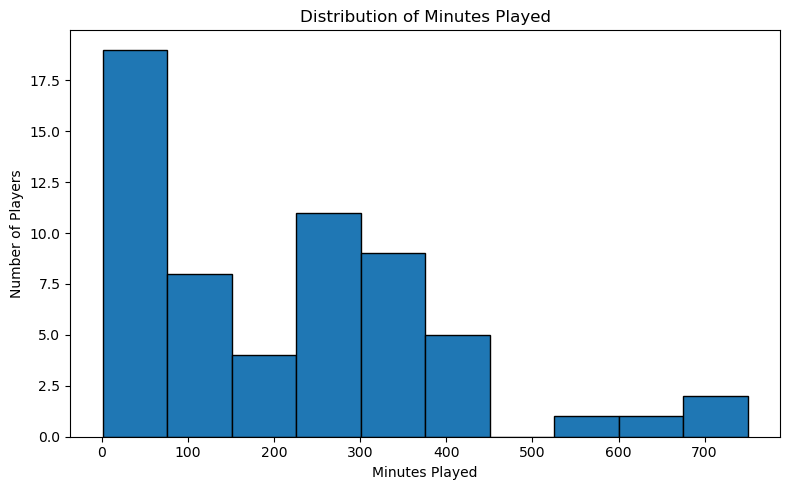

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    sample["minutes"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Minutes Played")
plt.xlabel("Minutes Played")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

## 7. Outlier Detection

Potential outliers are identified using the Interquartile Range (IQR)
method.

Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered
potential outliers.

In [12]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = sample[
    (sample["minutes"] < lower_bound) |
    (sample["minutes"] > upper_bound)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

print(f"\nPotential outliers: {len(outliers)}")

display(outliers[["player", "age", "minutes"]])

Q1: 54.50
Q3: 315.75
IQR: 261.25
Lower bound: -337.38
Upper bound: 707.62

Potential outliers: 2


,player,age,minutes
16,Pau Cubarsí,19,750.0
25,Mike Maignan,30,720.0


## 8. Box Plot: Older vs Younger Players

A box plot is used to compare the distribution of minutes played between
older and younger players.

The plot shows the median, interquartile range, overall spread, and
potential outliers for each age group.

<ipython-input-13-053312f69b9d>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


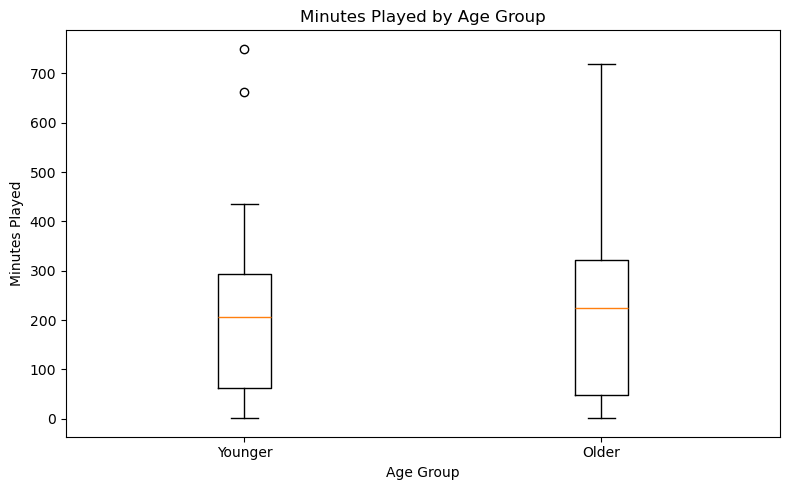

In [13]:
grp_older = sample.loc[
    sample["age_group"] == "Older",
    "minutes"
]

grp_younger = sample.loc[
    sample["age_group"] == "Younger",
    "minutes"
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [grp_younger, grp_older],
    labels=["Younger", "Older"]
)

plt.title("Minutes Played by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Minutes Played")

plt.tight_layout()
plt.show()

## 9. Group-Level Descriptive Statistics

The mean, median, standard deviation, and sample size are calculated
separately for older and younger players.

In [14]:
group_stats = sample.groupby("age_group")["minutes"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(group_stats)

,count,mean,median,std,min,max
age_group,,,,,,
Older,24,220.416667,225.0,193.717615,2.0,720.0
Younger,36,210.111111,207.0,180.146096,1.0,750.0


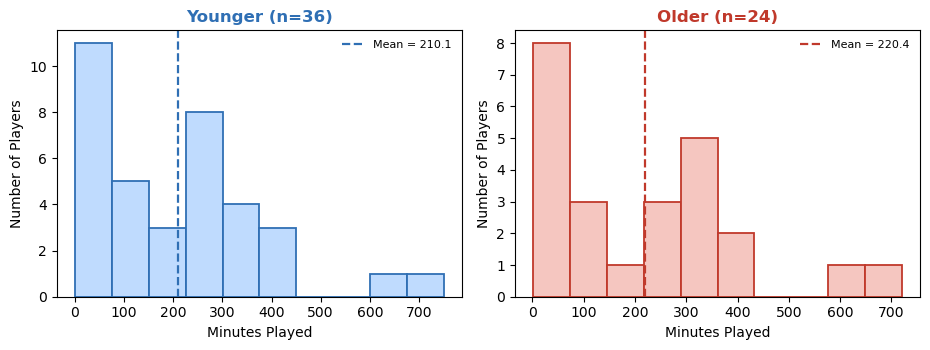

In [16]:

BLUE_EDGE = "#2F6FB4"
BLUE_FILL = "#BFDBFE"
RED_EDGE  = "#C0392B"
RED_FILL  = "#F5C6C0"

grp_older   = sample.loc[sample.age_group == "Older",   "minutes"]
grp_younger = sample.loc[sample.age_group == "Younger", "minutes"]

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6))

for ax, data, label, edge, fill in [
    (axes[0], grp_younger, f"Younger (n={len(grp_younger)})", BLUE_EDGE, BLUE_FILL),
    (axes[1], grp_older,   f"Older (n={len(grp_older)})",     RED_EDGE,  RED_FILL),
]:
    ax.hist(data, bins=10, color=fill, edgecolor=edge, linewidth=1.3)
    ax.axvline(data.mean(), color=edge, linestyle="--", linewidth=1.6,
               label=f"Mean = {data.mean():.1f}")
    ax.set_title(label, color=edge, fontsize=12, fontweight="bold")
    ax.set_xlabel("Minutes Played")
    ax.set_ylabel("Number of Players")
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig("q1_hist.png", dpi=200)
plt.show()

## 10. Statistical Assumption Checking

Before conducting the hypothesis test, the data are examined for
normality and differences in variance between the two groups.

Welch's t-test is used because it does not require equal population
variances.

In [17]:
# Normality test
older_shapiro = stats.shapiro(grp_older)
younger_shapiro = stats.shapiro(grp_younger)

print("Older group:")
print(f"Shapiro-Wilk statistic = {older_shapiro.statistic:.4f}")
print(f"p-value = {older_shapiro.pvalue:.4f}")

print("\nYounger group:")
print(f"Shapiro-Wilk statistic = {younger_shapiro.statistic:.4f}")
print(f"p-value = {younger_shapiro.pvalue:.4f}")

Older group:
Shapiro-Wilk statistic = 0.8993
p-value = 0.0208

Younger group:
Shapiro-Wilk statistic = 0.8919
p-value = 0.0021


In [18]:
# Variance test
levene_stat, levene_p = stats.levene(
    grp_older,
    grp_younger
)

print(f"Levene statistic = {levene_stat:.4f}")
print(f"Levene p-value = {levene_p:.4f}")

Levene statistic = 0.4525
Levene p-value = 0.5038


## 11. Research Question and Hypotheses

### Research Question

Is there a statistically significant difference in average minutes played
between older and younger players?

### Null Hypothesis (H₀)

There is no statistically significant difference in average minutes
played between older and younger players.

### Alternative Hypothesis (H₁)

There is a statistically significant difference in average minutes
played between older and younger players.

The significance level is set at α = 0.05.

## 12. Welch's Independent Samples t-Test

Welch's t-test is used to compare the mean minutes played between older
and younger players.

This test is preferred because it does not assume equal variances between
the two groups.

In [14]:
t_stat, p_val = stats.ttest_ind(
    grp_older,
    grp_younger,
    equal_var=False
)

print(f"Welch's t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\nDecision: Reject H0.")
    print("There is statistically significant evidence of a difference.")
else:
    print("\nDecision: Fail to reject H0.")
    print("There is insufficient evidence of a significant difference.")

Welch's t-statistic: 0.208
p-value: 0.8365

Decision: Fail to reject H0.
There is insufficient evidence of a significant difference.


## 13. Difference in Means and 95% Confidence Interval

The difference between the older and younger group means is calculated.

A 95% confidence interval is then constructed to quantify the uncertainty
around this estimated difference.

In [20]:
mean_older = grp_older.mean()
mean_younger = grp_younger.mean()

mean_difference = mean_older - mean_younger

n1 = len(grp_older)
n2 = len(grp_younger)

var1 = grp_older.var(ddof=1)
var2 = grp_younger.var(ddof=1)

se_difference = np.sqrt(
    (var1 / n1) + (var2 / n2)
)

df_welch = (
    ((var1 / n1) + (var2 / n2)) ** 2
    /
    (
        ((var1 / n1) ** 2 / (n1 - 1))
        +
        ((var2 / n2) ** 2 / (n2 - 1))
    )
)

t_critical = stats.t.ppf(
    0.975,
    df=df_welch
)

ci_low = mean_difference - t_critical * se_difference
ci_high = mean_difference + t_critical * se_difference

print(f"Older mean: {mean_older:.2f}")
print(f"Younger mean: {mean_younger:.2f}")
print(f"Mean difference: {mean_difference:.2f}")

print(f"\n95% CI: ({ci_low:.2f}, {ci_high:.2f})")

Older mean: 220.42
Younger mean: 210.11
Mean difference: 10.31

95% CI: (-89.58, 110.19)


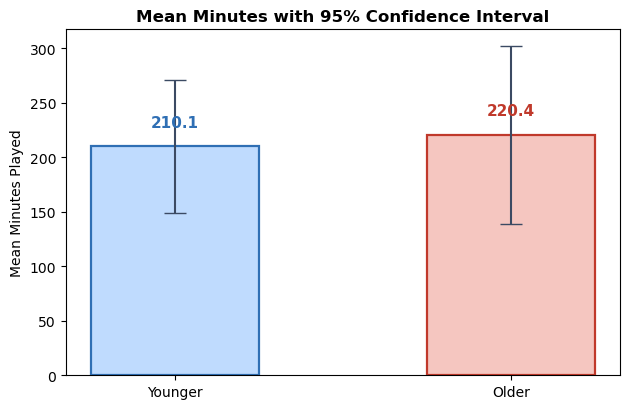

In [21]:
# Per-group 95% CI (for the error bars — separate from the CI on the difference above)
def group_ci(mean, var, n):
    se = np.sqrt(var / n)
    tc = stats.t.ppf(0.975, df=n - 1)
    return mean - tc * se, mean + tc * se

lo_o, hi_o = group_ci(mean_older, var1, n1)
lo_y, hi_y = group_ci(mean_younger, var2, n2)

fig, ax = plt.subplots(figsize=(6.4, 4.2))

labels = ["Younger", "Older"]
means  = [mean_younger, mean_older]
errs   = [[mean_younger - lo_y, mean_older - lo_o],
          [hi_y - mean_younger, hi_o - mean_older]]
colors = [BLUE_EDGE, RED_EDGE]

bars = ax.bar(labels, means, yerr=errs, capsize=8,
              color=[BLUE_FILL, RED_FILL], edgecolor=colors, linewidth=1.6,
              width=0.5, error_kw=dict(ecolor="#3B4A63", elinewidth=1.5))

for bar, mean, color in zip(bars, means, colors):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 18, f"{mean:.1f}",
            ha="center", fontsize=11, fontweight="bold", color=color)

ax.set_ylabel("Mean Minutes Played")
ax.set_title("Mean Minutes with 95% Confidence Interval", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("q1_ci.png", dpi=200)
plt.show()

## 14. Effect Size: Cohen's d

Cohen's d is calculated to measure the practical magnitude of the
difference between older and younger players.

Unlike the p-value, effect size indicates how large the observed
difference is.

In [16]:
pooled_sd = np.sqrt(
    (
        (n1 - 1) * var1 +
        (n2 - 1) * var2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = mean_difference / pooled_sd

print(f"Cohen's d = {cohens_d:.3f}")

if abs(cohens_d) < 0.2:
    interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    interpretation = "small"
elif abs(cohens_d) < 0.8:
    interpretation = "medium"
else:
    interpretation = "large"

print(f"Effect size interpretation: {interpretation}")

Cohen's d = 0.056
Effect size interpretation: negligible


## 15. Mann–Whitney U Test: Robustness Check

The Mann–Whitney U test is included as a non-parametric robustness check.

This provides an alternative comparison that does not rely on the same
distributional assumptions as the t-test.

In [17]:
u_stat, u_p = stats.mannwhitneyu(
    grp_older,
    grp_younger,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat:.3f}")
print(f"p-value: {u_p:.4f}")

if u_p < 0.05:
    print("The Mann-Whitney test indicates a significant difference.")
else:
    print("The Mann-Whitney test does not indicate a significant difference.")

Mann-Whitney U statistic: 439.500
p-value: 0.9159
The Mann-Whitney test does not indicate a significant difference.


## 16. Relationship Between Age and Minutes Played

A scatterplot is used to examine the overall relationship between
individual player age and minutes played.

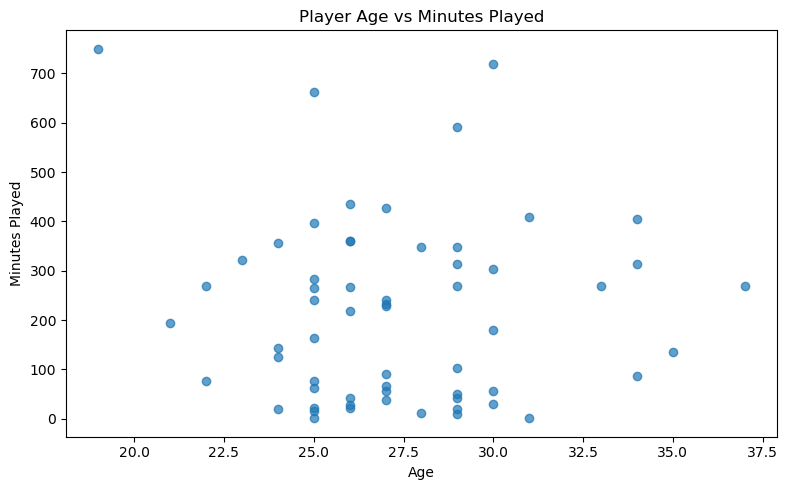

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    sample["age"],
    sample["minutes"],
    alpha=0.7
)

plt.title("Player Age vs Minutes Played")
plt.xlabel("Age")
plt.ylabel("Minutes Played")

plt.tight_layout()
plt.show()

## 17. Sample Size Sensitivity Analysis

The analysis is repeated using different sample sizes to determine
whether the statistical conclusion is sensitive to the selected sample.

The results are compared for n = 60, n = 100, and the full population
where possible.

In [19]:
sample_sizes = [60, 100, len(df)]

results = []

for size in sample_sizes:

    temp = df.sample(
        n=size,
        random_state=2027
    )

    older = temp.loc[
        temp["age_group"] == "Older",
        "minutes"
    ]

    younger = temp.loc[
        temp["age_group"] == "Younger",
        "minutes"
    ]

    t, p = stats.ttest_ind(
        older,
        younger,
        equal_var=False
    )

    results.append({
        "Sample size": size,
        "Older mean": older.mean(),
        "Younger mean": younger.mean(),
        "Difference": older.mean() - younger.mean(),
        "p-value": p
    })

sensitivity_results = pd.DataFrame(results)

display(sensitivity_results)

,Sample size,Older mean,Younger mean,Difference,p-value
0,60,220.416667,210.111111,10.305556,0.836466
1,100,232.625000,203.596154,29.028846,0.410301
2,1039,215.157025,193.286486,21.870538,0.027291


## 18. Final Conclusion
The mean minutes played in each group were compared using Welch's independent two sample t-test to see if there was a significant difference between the mean minutes played for both younger and older players. For a comprehensive assessment, descriptive statistics, visual analysis, confidence intervals, effect size analysis, and non-parametric robustness testing were also included in the analysis.

Descriptive results showed that older players played an average of 220.42 minutes, while younger ones did an average of 210.11 minutes, which yielded an observed mean difference of 10.31 minutes. The older group had a slightly higher average, but the Welch's t-test gave a p value of 0.8365 which is above the 0.05 level of significance. The null hypothesis was, therefore, not rejected and there was no statistical evidence that the mean playing times of the two age groups differed.

The 95% confidence interval for the mean difference was (−89.58, 110.19) minutes, which contained 0, indicating that the mean difference was not significantly different from zero. The wide interval stems from a considerable amount of uncertainty about the real size of the difference and indicates that the actual difference of 10.31 minutes is more likely due to normal sampling variation than to any real difference. The practical effect was negligible as Cohen's d was 0.056. The difference between the two groups is thus statistically and practically insignificant.

Minutes played was not normally distributed for either the older group (p = 0.0208) or the younger group (p = 0.0021) as demonstrated by Shapiro–Wilk tests. For this reason, a Welch t-test was selected, because it does not assume normal distribution of the data. In order to provide further checking, a non-parametric robustness test, namely a Mann–Whitney U test, was performed. This gave U = 439.500 and p = 0.9159 also with no indication of any significant difference. This conclusion is reinforced by an agreement between the t-test and the Mann–Whitney U test.

In addition, a sensitivity analysis was conducted using a sample size of 60, 100, and for all eligible players (n = 1,039). The results were quite different in small samples from what they were in larger samples, showing that small-sample estimates can be very sensitive to sampling variation. When analyzing the entire population of players, there was a statistically significant correlation between age and minutes played (Pearson r = 0.089, p = 0.004). With sample sizes this large, however, even quite small, and practically unimportant, effects can be termed "statistically significant": the correlation of age with playing time is almost zero, so that almost all of the variance in playing time can be explained by other factors. This is a good reminder that a statistically significant difference is not necessarily important, and also that the true effect of the treatment, if there is one, might be too small to reliably detect at the more modest statistical power of the smaller sample of 60.

In this sample, there is little evidence that the amount of time played is statistically significantly different for older and younger players. While older players on average played slightly more minutes, the difference was not statistically or practically significant, as seen from the confidence interval, the effect size, and the non-parametric robustness test, and was consistent across all of them.